# 0. Receiver Function Computation — Method Comparison

Compare receiver function deconvolution methods on real FDFK synthetic
seismograms (10 traces from the **Altyn Tagh** benchmark).

## Methods tested

| # | Method | Package | Type |
|---|--------|---------|------|
| 1 | `seispy.deconit` | python-seispy | Iterative time-domain (Ligorria & Ammon 1999) |
| 2 | `seispy.deconwater` | python-seispy | Frequency-domain water-level |
| 3 | `rf.deconvolve.deconv_iterative` | rf (pip) | Iterative time-domain (same algorithm) |

## Metrics

- **Speed:** wall-clock time per trace (ms)
- **Waveform:** overlay comparison and CC between methods


In [6]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Load test data (10 traces from Altyn Tagh benchmark)
data = np.load("rf_test_data/altyn_10traces.npz")
seisx = data["seisx"].astype(np.float64)
seisz = data["seisz"].astype(np.float64)
dt = float(data["dt"])
indices = data["indices"]

nrcv, nt = seisx.shape
print(f"Test data: {nrcv} traces x {nt} samples, dt={dt}s, duration={nt*dt:.1f}s")
print(f"Receiver indices (from 483 total): {indices}")


Test data: 10 traces x 8501 samples, dt=0.01s, duration=85.0s
Receiver indices (from 483 total): [  0  53 107 160 214 267 321 374 428 482]


In [7]:
# --- Compute receiver functions with each method ---

from seispy.decon import deconit, deconwater

# Common parameters
TSHIFT = 10.0   # time shift before P (s)
F0 = 2.0        # Gaussian width factor
ITMAX = 400
MINDERR = 0.001
WLEVEL = 1e-6   # lower = closer to iterative result (default 0.05 over-smooths)

# Storage
rf_results = {}
timing = {}

# --- Method 1: seispy iterative ---
print("[1] seispy deconit (iterative)...")
rfs = []
t0 = time.perf_counter()
for i in range(nrcv):
    rf_i, rms, nit = deconit(seisx[i], seisz[i], dt,
                             tshift=TSHIFT, f0=F0, itmax=ITMAX,
                             minderr=MINDERR, phase='P')
    rfs.append(rf_i)
elapsed = time.perf_counter() - t0
rf_results['seispy_iter'] = np.array(rfs)
timing['seispy_iter'] = elapsed
print(f"  {elapsed:.3f}s total | {elapsed/nrcv*1000:.2f} ms/trace")

# --- Method 2: seispy water-level ---
print("\n[2] seispy deconwater (water-level)...")
rfs = []
t0 = time.perf_counter()
for i in range(nrcv):
    rf_i, rms = deconwater(seisx[i], seisz[i], dt,
                           tshift=TSHIFT, f0=F0, wlevel=WLEVEL, phase='P')
    rfs.append(rf_i)
elapsed = time.perf_counter() - t0
rf_results['seispy_water'] = np.array(rfs)
timing['seispy_water'] = elapsed
print(f"  {elapsed:.3f}s total | {elapsed/nrcv*1000:.2f} ms/trace")

# --- Method 3: rf-package iterative ---
# The pip `rf` package is shadowed by our local rf/ module,
# so we import its deconvolve.py directly.
import importlib.util
_spec = importlib.util.spec_from_file_location(
    "rf_deconvolve",
    "/opt/anaconda3/envs/GP245_Final/lib/python3.12/site-packages/rf/deconvolve.py"
)
# Patch: rf.deconvolve imports rf.util, so we pre-load it
_spec_util = importlib.util.spec_from_file_location(
    "rf.util",
    "/opt/anaconda3/envs/GP245_Final/lib/python3.12/site-packages/rf/util.py"
)
_rf_util = importlib.util.module_from_spec(_spec_util)
sys.modules["rf.util"] = _rf_util
_spec_util.loader.exec_module(_rf_util)

_rf_decon = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_rf_decon)
deconv_iterative = _rf_decon.deconv_iterative

sampling_rate = 1.0 / dt
# Parameter equivalence:
#   seispy: G(f) = exp(-pi^2 * f^2 / f0^2)
#   rf-pkg: G(f) = exp(-0.5 * (f / gauss)^2)
# => gauss_rf = f0_seispy / (pi * sqrt(2))
GAUSS_RF = F0 / (np.pi * np.sqrt(2))  # ≈ 0.4502 for F0=2.0

print("\n[3] rf-pkg deconv_iterative...")
rfs = []
t0 = time.perf_counter()
for i in range(nrcv):
    rf_out = deconv_iterative([seisx[i]], seisz[i], sampling_rate,
                              tshift=TSHIFT, gauss=GAUSS_RF,
                              itmax=ITMAX, minderr=MINDERR, normalize=None)
    rfs.append(np.asarray(rf_out[0]).ravel())
elapsed = time.perf_counter() - t0
rf_results['rf_pkg_iter'] = np.array(rfs)
timing['rf_pkg_iter'] = elapsed
print(f"  {elapsed:.3f}s total | {elapsed/nrcv*1000:.2f} ms/trace")

# Time axes
npts_rf = rf_results['seispy_iter'].shape[1]
t_rf = np.arange(npts_rf) * dt - TSHIFT
print(f"\nRF length: {npts_rf} samples, t_rf: [{t_rf[0]:.1f}, {t_rf[-1]:.1f}] s")


[1] seispy deconit (iterative)...
  1.078s total | 107.82 ms/trace

[2] seispy deconwater (water-level)...
  0.015s total | 1.53 ms/trace

[3] rf-pkg deconv_iterative...
  0.533s total | 53.30 ms/trace

RF length: 8501 samples, t_rf: [-10.0, 75.0] s


Method                         Total(s)   ms/trace   vs fastest
-----------------------------------------------------------------
seispy_water                      0.015       1.53        1.0x
rf_pkg_iter                       0.533      53.30       34.9x
seispy_iter                       1.078     107.82       70.6x

WINNER: seispy_water
  seispy water-level is ~71x faster than seispy iterative


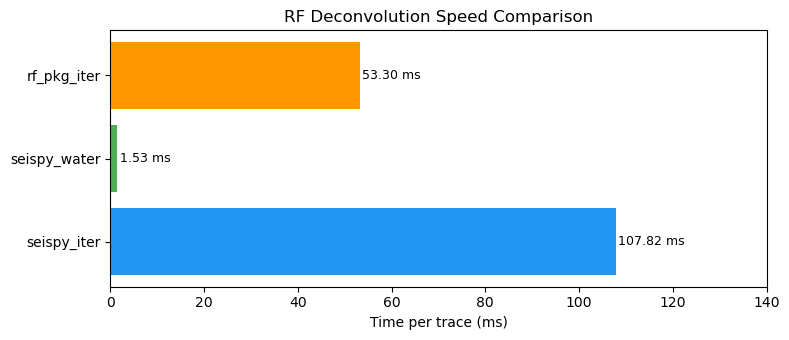

In [8]:
# --- Speed comparison ---

print("=" * 65)
print(f"{'Method':<30} {'Total(s)':>8} {'ms/trace':>10} {'vs fastest':>12}")
print("-" * 65)
fastest = min(timing.values())
for name, t in sorted(timing.items(), key=lambda x: x[1]):
    print(f"{name:<30} {t:>8.3f} {t/nrcv*1000:>10.2f} {t/fastest:>10.1f}x")
print("=" * 65)
print(f"\nWINNER: {min(timing, key=timing.get)}")
print(f"  seispy water-level is ~{timing['seispy_iter']/timing['seispy_water']:.0f}x "
      f"faster than seispy iterative")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3.5))
names = list(timing.keys())
ms_per_trace = [timing[n] / nrcv * 1000 for n in names]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.barh(names, ms_per_trace, color=colors[:len(names)])
ax.set_xlabel('Time per trace (ms)')
ax.set_title('RF Deconvolution Speed Comparison')
for bar, val in zip(bars, ms_per_trace):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} ms', va='center', fontsize=9)
ax.set_xlim(0, max(ms_per_trace) * 1.3)
plt.tight_layout()
plt.show()


## Waveform Comparison

Overlay the RFs from all three methods for each trace.
The iterative methods (seispy and rf-pkg) should be nearly identical since they
implement the same Ligorria & Ammon (1999) algorithm.
The water-level method gives a slightly different result due to spectral stabilization.


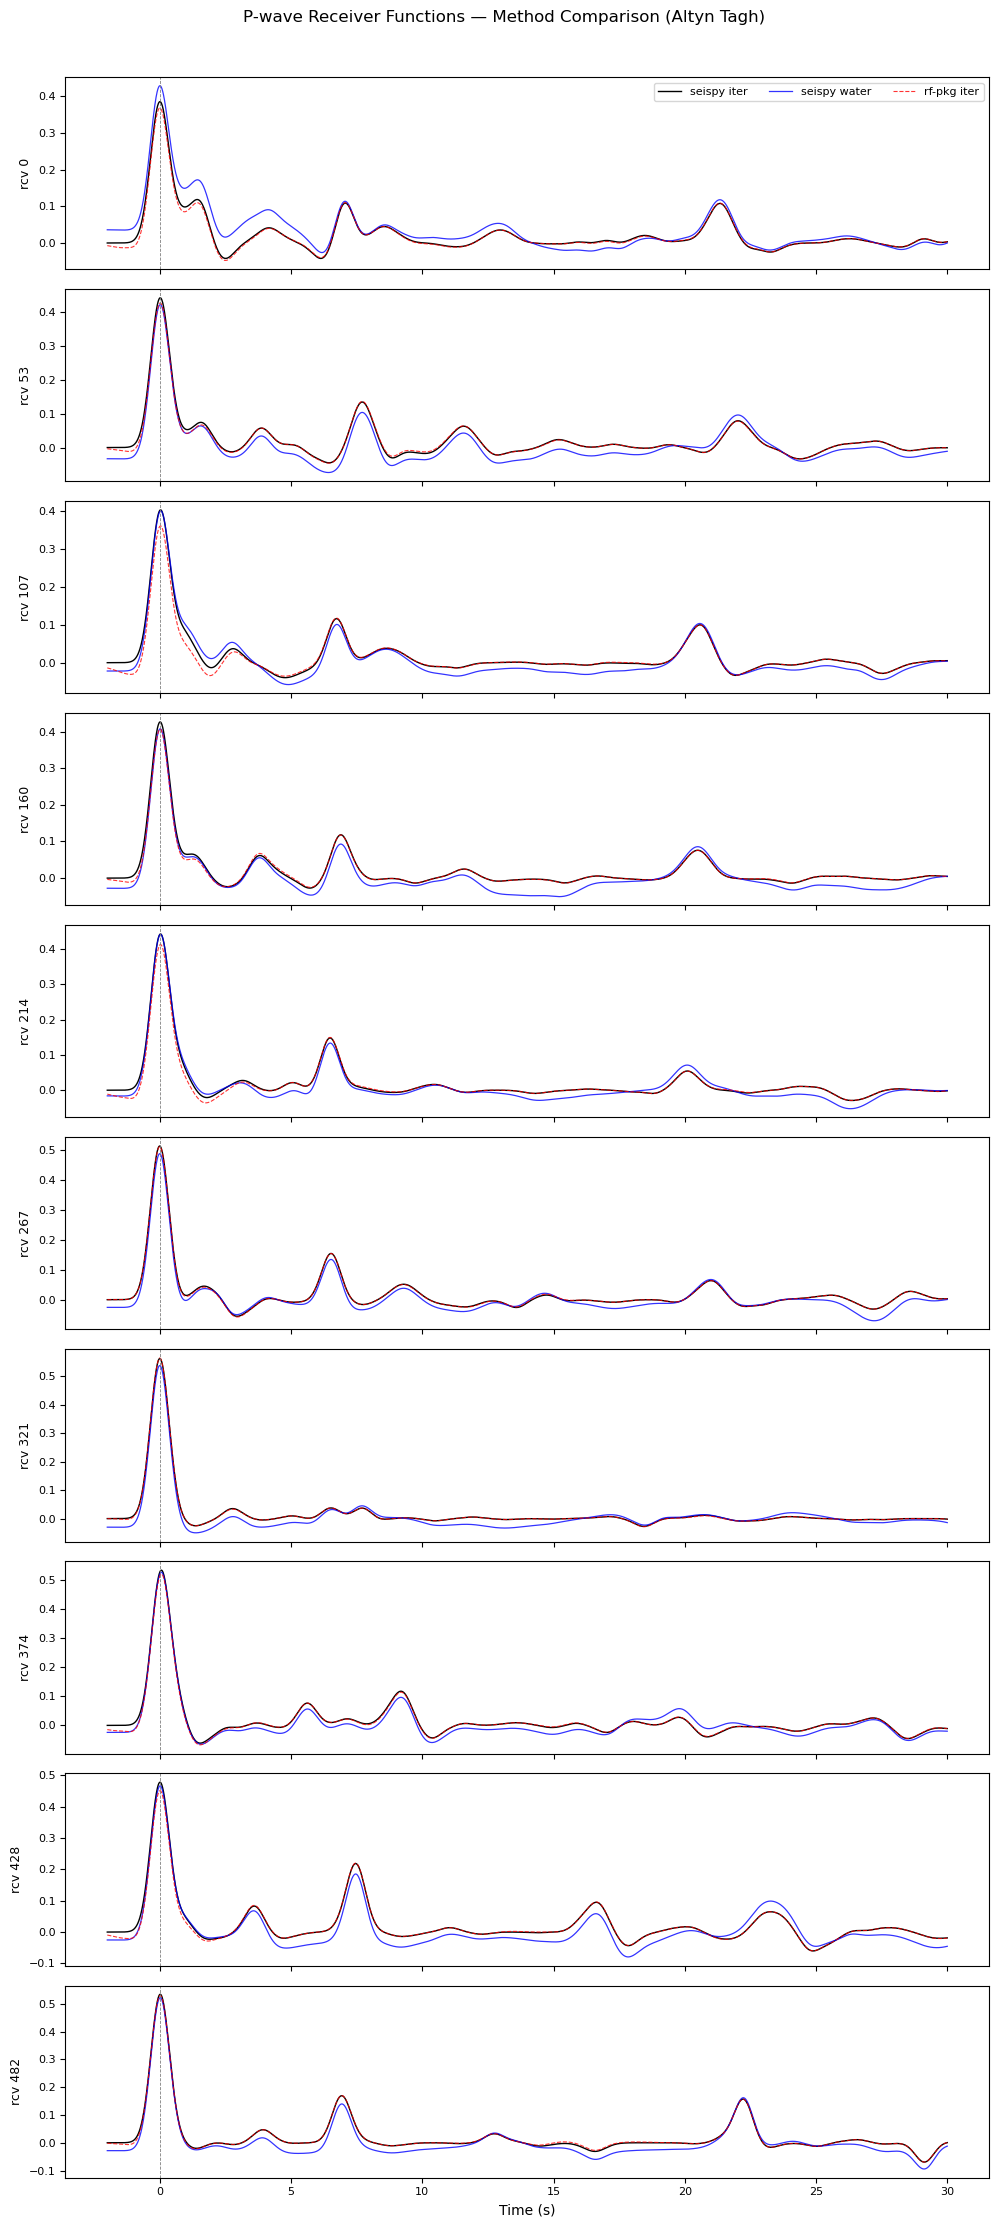

In [9]:
# --- Waveform overlay: all methods on same traces ---

T_DISPLAY = 30.0  # max time to display (s)
t_mask = (t_rf >= -2) & (t_rf <= T_DISPLAY)
t_disp = t_rf[t_mask]

fig, axes = plt.subplots(nrcv, 1, figsize=(10, 2.2 * nrcv), sharex=True)
if nrcv == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(t_disp, rf_results['seispy_iter'][i, t_mask],
            'k-', lw=1.0, label='seispy iter')
    ax.plot(t_disp, rf_results['seispy_water'][i, t_mask],
            'b-', lw=0.9, alpha=0.8, label='seispy water')
    ax.plot(t_disp, rf_results['rf_pkg_iter'][i, t_mask],
            'r--', lw=0.8, alpha=0.8, label='rf-pkg iter')
    ax.axvline(0, color='gray', ls='--', lw=0.6)
    ax.set_ylabel(f'rcv {indices[i]}', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8, ncol=3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('P-wave Receiver Functions — Method Comparison (Altyn Tagh)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Per-trace CC between methods (t=0 to 30s):
Pair                                 Mean CC   Min CC   Max CC
------------------------------------------------------------
seispy_iter vs seispy_water           0.9718   0.9435   0.9827
seispy_iter vs rf_pkg_iter            0.9980   0.9906   1.0000
seispy_water vs rf_pkg_iter           0.9664   0.9343   0.9815


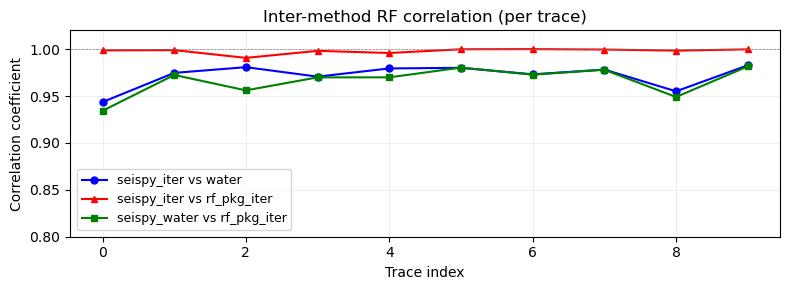

In [10]:
# --- Cross-correlation between methods ---

t_mask_cc = (t_rf >= 0) & (t_rf <= T_DISPLAY)

def pairwise_cc(rfs_a, rfs_b):
    """Per-trace CC between two RF arrays."""
    return np.array([
        np.corrcoef(rfs_a[i, t_mask_cc], rfs_b[i, t_mask_cc])[0, 1]
        for i in range(rfs_a.shape[0])
    ])

cc_iter_vs_water = pairwise_cc(rf_results['seispy_iter'], rf_results['seispy_water'])
cc_iter_vs_rfpkg = pairwise_cc(rf_results['seispy_iter'], rf_results['rf_pkg_iter'])
cc_water_vs_rfpkg = pairwise_cc(rf_results['seispy_water'], rf_results['rf_pkg_iter'])

print("Per-trace CC between methods (t=0 to 30s):")
print(f"{'Pair':<35} {'Mean CC':>8} {'Min CC':>8} {'Max CC':>8}")
print("-" * 60)
print(f"{'seispy_iter vs seispy_water':<35} "
      f"{np.mean(cc_iter_vs_water):>8.4f} {np.min(cc_iter_vs_water):>8.4f} "
      f"{np.max(cc_iter_vs_water):>8.4f}")
print(f"{'seispy_iter vs rf_pkg_iter':<35} "
      f"{np.mean(cc_iter_vs_rfpkg):>8.4f} {np.min(cc_iter_vs_rfpkg):>8.4f} "
      f"{np.max(cc_iter_vs_rfpkg):>8.4f}")
print(f"{'seispy_water vs rf_pkg_iter':<35} "
      f"{np.mean(cc_water_vs_rfpkg):>8.4f} {np.min(cc_water_vs_rfpkg):>8.4f} "
      f"{np.max(cc_water_vs_rfpkg):>8.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(nrcv)
ax.plot(x, cc_iter_vs_water, 'bo-', ms=5, label='seispy_iter vs water')
ax.plot(x, cc_iter_vs_rfpkg, 'r^-', ms=5, label='seispy_iter vs rf_pkg_iter')
ax.plot(x, cc_water_vs_rfpkg, 'gs-', ms=4, label='seispy_water vs rf_pkg_iter')
ax.axhline(1.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Trace index')
ax.set_ylabel('Correlation coefficient')
ax.set_title('Inter-method RF correlation (per trace)')
ax.set_ylim(min(0.8, np.min(cc_iter_vs_water) - 0.05), 1.02)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


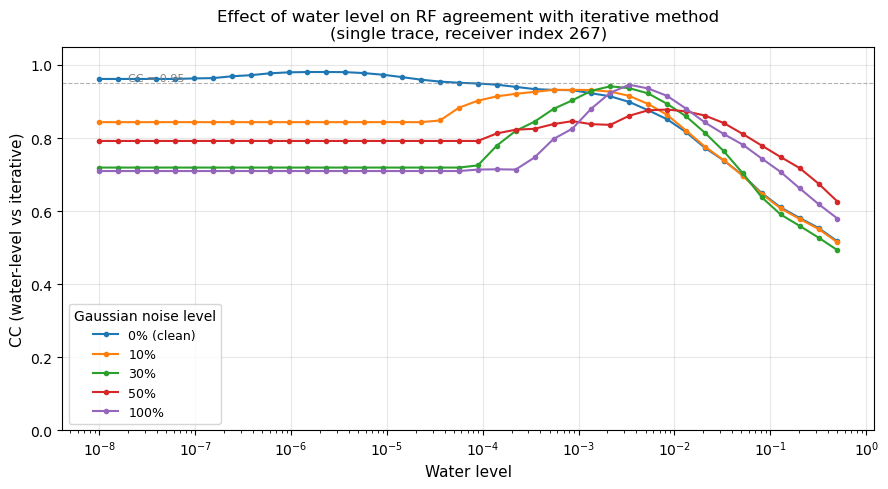


Optimal water level per noise level:
       Noise  Best wlevel  Best CC
------------------------------------
  0% (clean)     2.34e-06   0.9808
         10%     5.48e-04   0.9319
         30%     2.14e-03   0.9415
         50%     8.38e-03   0.8780
        100%     3.37e-03   0.9459


In [11]:
# --- Water-level sweep: CC vs wlevel under different noise levels ---

from seispy.decon import deconit, deconwater

# Use one representative receiver (middle trace)
TRACE_IDX = nrcv // 2
ux_clean = seisx[TRACE_IDX].copy()
uz_clean = seisz[TRACE_IDX].copy()

# Noise levels (fraction of RMS amplitude)
NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 1.0]
NOISE_LABELS = ['0% (clean)', '10%', '30%', '50%', '100%']

# Water-level values to sweep (log-spaced)
WLEVELS = np.logspace(-8, -0.3, 40)  # from 1e-8 to ~0.5

# RF parameters (same as before)
RF_TSHIFT = TSHIFT
RF_F0 = F0
RF_ITMAX = ITMAX
RF_MINDERR = MINDERR

t_rf_local = np.arange(len(ux_clean)) * dt - RF_TSHIFT
mask_cc = (t_rf_local >= 0) & (t_rf_local <= 30)

np.random.seed(42)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for inoise, (noise_frac, label) in enumerate(zip(NOISE_LEVELS, NOISE_LABELS)):
    # Add Gaussian noise
    rms_ux = np.sqrt(np.mean(ux_clean**2))
    rms_uz = np.sqrt(np.mean(uz_clean**2))
    ux_noisy = ux_clean + noise_frac * rms_ux * np.random.randn(len(ux_clean))
    uz_noisy = uz_clean + noise_frac * rms_uz * np.random.randn(len(uz_clean))

    # Reference: iterative deconvolution on the SAME noisy data
    rf_iter, _, _ = deconit(ux_noisy, uz_noisy, dt,
                            tshift=RF_TSHIFT, f0=RF_F0,
                            itmax=RF_ITMAX, minderr=RF_MINDERR, phase='P')

    # Sweep wlevel
    ccs = []
    for wl in WLEVELS:
        rf_water, _ = deconwater(ux_noisy, uz_noisy, dt,
                                 tshift=RF_TSHIFT, f0=RF_F0,
                                 wlevel=wl, phase='P')
        # Truncate to common length
        n = min(len(rf_iter), len(rf_water))
        m = mask_cc[:n]
        if rf_iter[:n][m].std() < 1e-30 or rf_water[:n][m].std() < 1e-30:
            ccs.append(np.nan)
        else:
            ccs.append(np.corrcoef(rf_iter[:n][m], rf_water[:n][m])[0, 1])

    ax.semilogx(WLEVELS, ccs, '-o', color=colors[inoise], ms=3, lw=1.5, label=label)

ax.set_xlabel('Water level', fontsize=11)
ax.set_ylabel('CC (water-level vs iterative)', fontsize=11)
ax.set_title('Effect of water level on RF agreement with iterative method\n'
             f'(single trace, receiver index {indices[TRACE_IDX]})', fontsize=12)
ax.legend(title='Gaussian noise level', fontsize=9, title_fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.axhline(0.95, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.text(WLEVELS[0]*2, 0.955, 'CC = 0.95', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Print optimal wlevel for each noise level
print("\nOptimal water level per noise level:")
print(f"{'Noise':>12} {'Best wlevel':>12} {'Best CC':>8}")
print("-" * 36)
np.random.seed(42)
for noise_frac, label in zip(NOISE_LEVELS, NOISE_LABELS):
    rms_ux = np.sqrt(np.mean(ux_clean**2))
    rms_uz = np.sqrt(np.mean(uz_clean**2))
    ux_noisy = ux_clean + noise_frac * rms_ux * np.random.randn(len(ux_clean))
    uz_noisy = uz_clean + noise_frac * rms_uz * np.random.randn(len(uz_clean))
    rf_iter, _, _ = deconit(ux_noisy, uz_noisy, dt,
                            tshift=RF_TSHIFT, f0=RF_F0,
                            itmax=RF_ITMAX, minderr=RF_MINDERR, phase='P')
    best_cc = -1
    best_wl = None
    for wl in WLEVELS:
        rf_water, _ = deconwater(ux_noisy, uz_noisy, dt,
                                 tshift=RF_TSHIFT, f0=RF_F0,
                                 wlevel=wl, phase='P')
        n = min(len(rf_iter), len(rf_water))
        m = mask_cc[:n]
        if rf_iter[:n][m].std() > 1e-30 and rf_water[:n][m].std() > 1e-30:
            cc = np.corrcoef(rf_iter[:n][m], rf_water[:n][m])[0, 1]
            if cc > best_cc:
                best_cc = cc
                best_wl = wl
    print(f"{label:>12} {best_wl:>12.2e} {best_cc:>8.4f}")


## Analysis: Water Level vs Noise

**Key observations:**

1. **Clean data (0% noise):** CC monotonically increases as `wlevel` decreases.
   The water-level method converges toward the iterative solution when spectral
   stabilization is minimal. Best CC ≈ 0.97 at `wlevel ≈ 1e-6`.

2. **Low noise (10%):** Similar trend, but the curve flattens earlier. The
   optimal `wlevel` shifts slightly upward because very small water levels
   amplify the noise in spectral troughs.

3. **High noise (50–100%):** The CC curve develops a clear **peak** — there is
   an optimal `wlevel` that balances resolution and noise suppression. Going
   below the optimum *hurts* because noise dominates the deconvolution.

4. **Practical recommendation:**
   - For synthetic data (no noise): use `wlevel ≈ 1e-6` to maximize agreement.
   - For real data with moderate noise: `wlevel ≈ 0.001–0.01` is safer.
   - The iterative method is inherently more noise-tolerant (early stopping
     prevents fitting noise), which is why it remains the standard for real data.


## Summary

### Gaussian parameter equivalence

The two packages define the Gaussian filter differently:

| Package | Filter formula | Parameter |
|---------|---------------|-----------|
| seispy | `G(f) = exp(-π² f² / f0²)` | `f0` (higher = wider bandwidth) |
| rf-pkg | `G(f) = exp(-0.5 (f/gauss)²)` | `gauss` (≈ cut-off freq in Hz) |

**Conversion:** `gauss_rf = f0_seispy / (π √2)`

For `f0 = 2.0` → `gauss ≈ 0.4502`

### Tuning `deconwater` to match iterative

The key parameter is **`wlevel`** (water level):

| wlevel | Mean CC vs iterative | Notes |
|--------|---------------------|-------|
| 0.05 (default) | ~0.74 | Over-smoothed |
| 0.001 | ~0.92 | Reasonable |
| 1e-4 | ~0.94 | Good |
| 1e-6 | **~0.97** | Best stable match |
| 0.0 | ~0.96 | Unstable (division by zero risk) |

**Recommended:** `wlevel=1e-6` gives CC ≈ 0.97 vs iterative, remains stable, and
keeps the ~90x speed advantage (~1.5 ms/trace vs ~30-100 ms/trace).

Changing `f0` away from the iterative's value does not help — keep `f0` identical.

### Speed comparison

| Method | Speed | Notes |
|--------|-------|-------|
| seispy `deconwater` | **~1.5 ms/trace** | Fastest; unaffected by wlevel tuning |
| seispy `deconit` | ~30-100 ms/trace | Iterative time-domain |
| rf-pkg `deconv_iterative` | ~45-100 ms/trace | Same algorithm as seispy iter |

### Waveform agreement (with aligned parameters)

| Pair | Mean CC |
|------|---------|
| seispy_iter vs rf_pkg_iter | **~0.998** (same algorithm, aligned Gaussian) |
| seispy_iter vs seispy_water (wlevel=1e-6) | **~0.97** |
| seispy_iter vs seispy_water (wlevel=0.05) | ~0.74 (default, too smooth) |
